In [16]:
from pathlib import Path
import sys

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Find the project root before importing from src.
cwd = Path.cwd()
if (cwd / "src" / "load_data.py").exists():
    project_dir = cwd
elif (cwd.parent / "src" / "load_data.py").exists():
    project_dir = cwd.parent
else:
    raise FileNotFoundError(f"Cannot find src/load_data.py in {cwd} or {cwd.parent}")

sys.path.insert(0, str(project_dir))
from src.load_data import load


In [17]:

print("Working directory:", cwd)
print("Using project folder:", project_dir)
df = load()
display(df.head())



Working directory: c:\Users\Administrator\Desktop\ironhack\Mini_Project\notebooks
Using project folder: c:\Users\Administrator\Desktop\ironhack\Mini_Project


,Unnamed: 0,store_ID,day_of_week,date,nb_customers_on_day,open,promotion,state_holiday,school_holiday,sales
0,425390,366,4,2013-04-18,517,1,0,0,0,4422
1,291687,394,6,2015-04-11,694,1,0,0,0,8297
2,411278,807,4,2013-08-29,970,1,1,0,0,9729
3,664714,802,2,2013-05-28,473,1,1,0,0,6513
4,540835,726,4,2013-10-10,1068,1,1,0,0,10882


In [18]:
#Exploratory Data Analysis (EDA)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 640840 entries, 0 to 640839
Data columns (total 10 columns):
 #   Column               Non-Null Count   Dtype
---  ------               --------------   -----
 0   Unnamed: 0           640840 non-null  int64
 1   store_ID             640840 non-null  int64
 2   day_of_week          640840 non-null  int64
 3   date                 640840 non-null  str  
 4   nb_customers_on_day  640840 non-null  int64
 5   open                 640840 non-null  int64
 6   promotion            640840 non-null  int64
 7   state_holiday        640840 non-null  str  
 8   school_holiday       640840 non-null  int64
 9   sales                640840 non-null  int64
dtypes: int64(8), str(2)
memory usage: 55.6 MB


In [19]:
#Display the rows and columns of the data frame
df.shape


(640840, 10)

In [20]:
#display the column names of the data frame
df.columns

Index(['Unnamed: 0', 'store_ID', 'day_of_week', 'date', 'nb_customers_on_day',
       'open', 'promotion', 'state_holiday', 'school_holiday', 'sales'],
      dtype='str')

In [21]:
#check for missing values in the data frame
df.isnull().sum()

Unnamed: 0             0
store_ID               0
day_of_week            0
date                   0
nb_customers_on_day    0
open                   0
promotion              0
state_holiday          0
school_holiday         0
sales                  0
dtype: int64

In [22]:
#describe the data frame
df.describe()

,Unnamed: 0,store_ID,day_of_week,nb_customers_on_day,open,promotion,school_holiday,sales
count,640840.000000,640840.000000,640840.000000,640840.000000,640840.000000,640840.000000,640840.000000,640840.000000
mean,355990.675084,558.211348,4.000189,633.398577,0.830185,0.381718,0.178472,5777.469011
std,205536.290268,321.878521,1.996478,464.094416,0.375470,0.485808,0.382910,3851.338083
min,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,178075.750000,280.000000,2.000000,405.000000,1.000000,0.000000,0.000000,3731.000000
50%,355948.500000,558.000000,4.000000,609.000000,1.000000,0.000000,0.000000,5746.000000
75%,533959.250000,837.000000,6.000000,838.000000,1.000000,1.000000,0.000000,7860.000000
max,712044.000000,1115.000000,7.000000,5458.000000,1.000000,1.000000,1.000000,41551.000000


In [23]:
#convert the 'state_holiday' column to integer type
#df['state_holiday'] = pd.to_numeric(df['state_holiday'], errors='coerce')
print(df['state_holiday'].value_counts(dropna=False))
print(df['state_holiday'].dtype)
print(df["state_holiday"].nunique(dropna=True))


state_holiday
0    621160
a     12842
b      4214
c      2624
Name: count, dtype: int64
str
4


In [24]:
df.head()

,Unnamed: 0,store_ID,day_of_week,date,nb_customers_on_day,open,promotion,state_holiday,school_holiday,sales
0,425390,366,4,2013-04-18,517,1,0,0,0,4422
1,291687,394,6,2015-04-11,694,1,0,0,0,8297
2,411278,807,4,2013-08-29,970,1,1,0,0,9729
3,664714,802,2,2013-05-28,473,1,1,0,0,6513
4,540835,726,4,2013-10-10,1068,1,1,0,0,10882


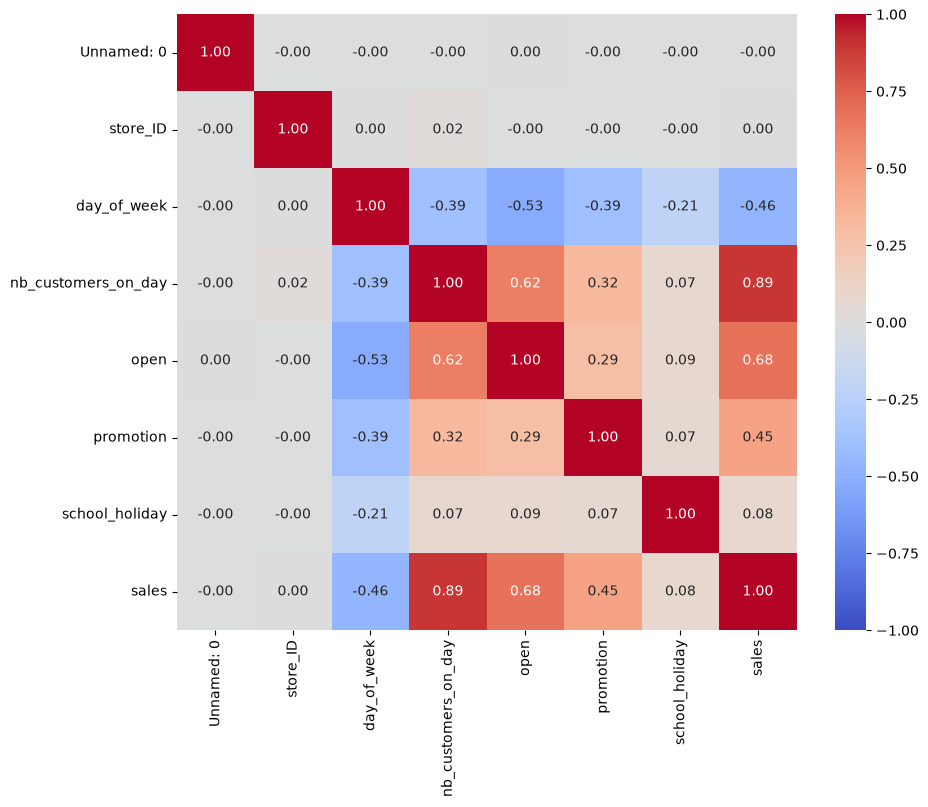

In [25]:
#heatmap to show only columns with a valid correlation
numeric_df = df.select_dtypes(include="number")
numeric_df = numeric_df.loc[:, numeric_df.nunique(dropna=True) > 1]

plt.figure(figsize=(10, 8))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm",
            vmin=-1, vmax=1, fmt=".2f")
plt.show()

### "store_id" and "Unnamed 0" columns don't have an impact on sales (correlation = 0), so we drop them as they are not useful in the analysis.

In [34]:
#drop the unnecessary columns from the data frame
drop_columns =df.drop(columns=["Unnamed: 0", "store_ID"], inplace=True, )



In [27]:
display(df)

,Unnamed: 0,store_ID,day_of_week,date,nb_customers_on_day,open,promotion,state_holiday,school_holiday,sales
0,425390,366,4,2013-04-18,517,1,0,0,0,4422
1,291687,394,6,2015-04-11,694,1,0,0,0,8297
2,411278,807,4,2013-08-29,970,1,1,0,0,9729
3,664714,802,2,2013-05-28,473,1,1,0,0,6513
4,540835,726,4,2013-10-10,1068,1,1,0,0,10882
...,...,...,...,...,...,...,...,...,...,...
640835,359783,409,6,2013-10-26,483,1,0,0,0,4553
640836,152315,97,1,2014-04-14,987,1,1,0,0,12307
640837,117952,987,1,2014-07-07,925,1,0,0,0,6800
640838,435829,1084,4,2014-06-12,725,1,0,0,0,5344


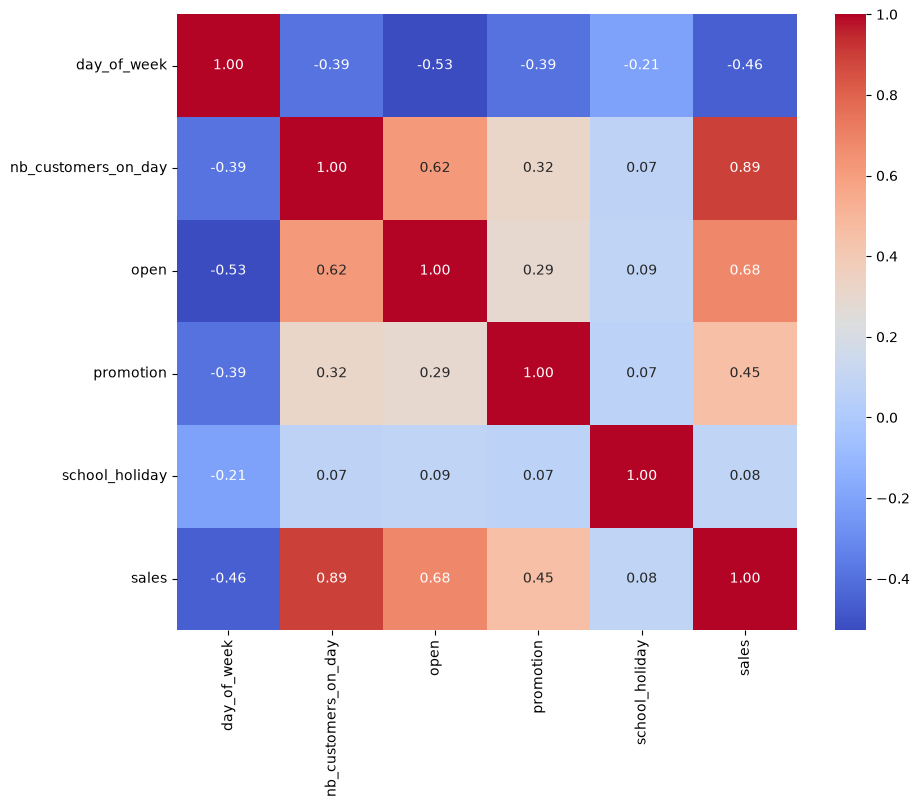

In [35]:
#heat map of the correlation between the columns
plt.figure(figsize=(10, 8)) 

corr = df.drop(columns=["date", "state_holiday"]).corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.show()

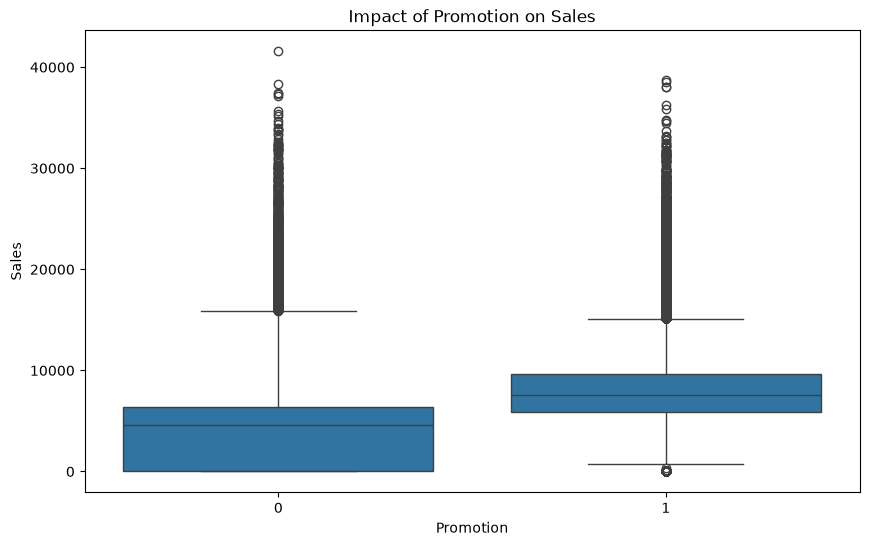

In [29]:
#visualize the impact of Promotion on Sales using a boxplot 
plt.figure(figsize=(10, 6))
sns.boxplot(x=df["promotion"], y=df["sales"], data=df)  
plt.title("Impact of Promotion on Sales")
plt.xlabel("Promotion") 
plt.ylabel("Sales") 
plt.show()

In [30]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 640840 entries, 0 to 640839
Data columns (total 10 columns):
 #   Column               Non-Null Count   Dtype
---  ------               --------------   -----
 0   Unnamed: 0           640840 non-null  int64
 1   store_ID             640840 non-null  int64
 2   day_of_week          640840 non-null  int64
 3   date                 640840 non-null  str  
 4   nb_customers_on_day  640840 non-null  int64
 5   open                 640840 non-null  int64
 6   promotion            640840 non-null  int64
 7   state_holiday        640840 non-null  str  
 8   school_holiday       640840 non-null  int64
 9   sales                640840 non-null  int64
dtypes: int64(8), str(2)
memory usage: 55.6 MB


In [33]:

# Work on a copy so the original df from our EDA stays unchanged.
model_df = df.copy()

# Convert date strings such as "2015-01-24" into real dates.
# Convert sales to numbers and remove rows where either value is invalid.
model_df["date"] = pd.to_datetime(model_df["date"], errors="coerce")
model_df["sales"] = pd.to_numeric(model_df["sales"], errors="coerce")
model_df = model_df.dropna(subset=["date", "sales"])

# Put rows in chronological order for a future-sales prediction task.
model_df = model_df.sort_values("date").reset_index(drop=True)

# Extract information from the date that we would know before the day begins.
model_df["year"] = model_df["date"].dt.year
model_df["month"] = model_df["date"].dt.month
model_df["day_of_month"] = model_df["date"].dt.day
model_df["day_of_week"] = model_df["date"].dt.dayofweek + 1

# Store IDs are labels for stores, not numerical quantities.
# Holiday codes (0, a, b, c) are categories too.
# Later, OneHotEncoder will turn these categories into model inputs.
model_df["store_ID"] = model_df["store_ID"].astype(str)
model_df["state_holiday"] = model_df["state_holiday"].astype(str)

# X contains the information used to make predictions.
# y contains the answer we want the model to learn: daily sales.
#
# Remove:
# - sales: the value we are trying to predict
# - date: we already extracted useful calendar information from it
# - nb_customers_on_day: unknown before the day begins
# - Unnamed columns: row numbers saved when the CSV was created
X = model_df.drop(
    columns=[
        "sales",
        "date",
        "nb_customers_on_day",
        "Unnamed: 0",
        "Unnamed 0",
    ],
    errors="ignore",
)
y = model_df["sales"]

# Find the date where the final 20% of distinct dates begins.
# Splitting on distinct dates keeps every store's rows for one date together.
dates = model_df["date"].drop_duplicates().sort_values()
cutoff_date = dates.iloc[int(len(dates) * 0.8)]

# Earlier dates are training data; later dates are test data.
train_mask = model_df["date"] < cutoff_date

X_train = X.loc[train_mask]
X_test = X.loc[~train_mask]
y_train = y.loc[train_mask]
y_test = y.loc[~train_mask]

# Check the split and make sure only intended features remain.
print("Training rows:", len(X_train))
print("Test rows:", len(X_test))
print("First test date:", cutoff_date.date())
print("Features:", X_train.columns.tolist())

Training rows: 508118
Test rows: 132722
First test date: 2015-01-24
Features: ['store_ID', 'day_of_week', 'open', 'promotion', 'state_holiday', 'school_holiday', 'year', 'month', 'day_of_month']
